<a href="https://colab.research.google.com/github/MGabrielaVOliveira/Project-Ecommerce-Reviews---Sentiment-Analysis/blob/main/SentimentAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1.1 INITIAL CONFIGURATION




In [ ]:

!pip install -q pandas scikit-learn matplotlib nltk textblob spacy groq
!python -m spacy download pt_core_news_sm -q
!git clone -q https://github.com/rafjaa/LeIA.git
!git clone -q https://github.com/guilhermeonrails/LeIA-MBA.git

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 30.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
fatal: destination path 'LeIA' already exists and is not an empty directory.
fatal: destination path 'LeIA-MBA' already exists and is not an empty directory.


In [ ]:
import sys
import importlib.util
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (precision_score,recall_score,f1_score,accuracy_score,confusion_matrix,classification_report,ConfusionMatrixDisplay)
import nltk
nltk.download("vader_lexicon", quiet=True)
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from textblob import TextBlob
import spacy
from groq import Groq


### 1.2 PROCESSING DATA

In [ ]:
def carregar_leia(path_module, name_module):
    spec = importlib.util.spec_from_file_location(name_module, path_module)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module

SentimentIntensityAnalyzerPT = carregar_leia("LeIA/leia.py", "leia_padrao").SentimentIntensityAnalyzer
SentimentIntensityAnalyzerMBA = carregar_leia("LeIA-MBA/leia.py", "leia_mba").SentimentIntensityAnalyzer

In [ ]:
df = pd.read_csv("olist_order_reviews_dataset.csv")

In [ ]:
df = df.dropna(subset=["review_comment_message"])

In [ ]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df.head(10)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,d3c62500417e7eeab7c6ac2151b67357,301b453872955e08f7aed322d6a0753a,4,NaN,Um produto como uma carteira somente poderia s...,2017-12-21 00:00:00,2017-12-22 17:52:15
1,0f952ad4dfb88a77f12211a4038c70dd,f9281da15642bc69f27307e1dc987b30,5,muito bom produto,"Entrega no prazo , bom produto .",2018-05-25 00:00:00,2018-05-26 16:27:02
2,067b7c9c760d8bda7a2c38fb1f3fdf6e,e747b099854432937d27178c640102bf,5,NaN,entrega rápida,2017-10-04 00:00:00,2017-10-05 11:09:27
3,62f78be17aa2ef7db33e5781e00e7dc8,3f3e4083688c07129239450773e84282,5,NaN,Chegou no prazo e atendeu as minhas espectativas,2018-02-09 00:00:00,2018-02-15 16:33:30
4,9fcdf7983153b632cdbab78bf7d7f83a,b3b8133868458b6acf08ea6ffc22e3f2,5,NaN,Logística ótima entregue antes do prazo previs...,2017-08-19 00:00:00,2017-08-26 17:03:10
5,a2e0d982abe0a650156ec056ca4d1b85,a4244008bc97ae9cdc3807237fa83229,5,Satisfeita,"Entrega no prazo combinado , chegou certinho r...",2018-07-04 00:00:00,2018-07-07 15:50:37
6,74ef1abcf8bfb7ca756b7cd788ee366b,2b4d04cfb81d2dbb1ab48f9e2a7ac6b9,1,NaN,Vocês me enviaram faltando 3 cortinas. E agora?,2018-03-24 00:00:00,2018-03-27 00:28:24
7,1faf54dfeb5d82e5218a8ca9433e90b8,c38db22a86ae94a2a5a9dd2d5700f6cb,4,Entrega demorada,A encomenda demorou muito a chegar mas chegou ...,2018-06-01 00:00:00,2018-06-19 15:14:22
8,2070cfae604cb0be67d5967716a68107,fde2b2f46bb69e2359b74ff7606de899,4,NaN,produto dentro do esperado sem defeitos,2017-07-04 00:00:00,2017-07-05 15:41:12
9,5bb1b76de6b52930ca68babe90a89935,7cc23d880ead6eb7ebecb6292435b6d6,4,NaN,Chegou no prazo !,2018-02-10 00:00:00,2018-02-12 19:41:47


In [ ]:
feelings = []

for nota in df["review_score"]:
    if nota >= 4 :
        feelings.append("positive")
    else:
        feelings.append("negative")  #I didn't classify score-3 reviews as neutral, because when I inspected them manually, most were actually negative in tone.

df["feeling"] = feelings

In [ ]:
df.head(10)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,feeling
0,d3c62500417e7eeab7c6ac2151b67357,301b453872955e08f7aed322d6a0753a,4,NaN,Um produto como uma carteira somente poderia s...,2017-12-21 00:00:00,2017-12-22 17:52:15,positive
1,0f952ad4dfb88a77f12211a4038c70dd,f9281da15642bc69f27307e1dc987b30,5,muito bom produto,"Entrega no prazo , bom produto .",2018-05-25 00:00:00,2018-05-26 16:27:02,positive
2,067b7c9c760d8bda7a2c38fb1f3fdf6e,e747b099854432937d27178c640102bf,5,NaN,entrega rápida,2017-10-04 00:00:00,2017-10-05 11:09:27,positive
3,62f78be17aa2ef7db33e5781e00e7dc8,3f3e4083688c07129239450773e84282,5,NaN,Chegou no prazo e atendeu as minhas espectativas,2018-02-09 00:00:00,2018-02-15 16:33:30,positive
4,9fcdf7983153b632cdbab78bf7d7f83a,b3b8133868458b6acf08ea6ffc22e3f2,5,NaN,Logística ótima entregue antes do prazo previs...,2017-08-19 00:00:00,2017-08-26 17:03:10,positive
5,a2e0d982abe0a650156ec056ca4d1b85,a4244008bc97ae9cdc3807237fa83229,5,Satisfeita,"Entrega no prazo combinado , chegou certinho r...",2018-07-04 00:00:00,2018-07-07 15:50:37,positive
6,74ef1abcf8bfb7ca756b7cd788ee366b,2b4d04cfb81d2dbb1ab48f9e2a7ac6b9,1,NaN,Vocês me enviaram faltando 3 cortinas. E agora?,2018-03-24 00:00:00,2018-03-27 00:28:24,negative
7,1faf54dfeb5d82e5218a8ca9433e90b8,c38db22a86ae94a2a5a9dd2d5700f6cb,4,Entrega demorada,A encomenda demorou muito a chegar mas chegou ...,2018-06-01 00:00:00,2018-06-19 15:14:22,positive
8,2070cfae604cb0be67d5967716a68107,fde2b2f46bb69e2359b74ff7606de899,4,NaN,produto dentro do esperado sem defeitos,2017-07-04 00:00:00,2017-07-05 15:41:12,positive
9,5bb1b76de6b52930ca68babe90a89935,7cc23d880ead6eb7ebecb6292435b6d6,4,NaN,Chegou no prazo !,2018-02-10 00:00:00,2018-02-12 19:41:47,positive


In [ ]:
df["feeling"].value_counts()

,count
feeling,
positive,26530
negative,14447


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df["review_comment_message"], df["feeling"],
    test_size=0.2, random_state=42, stratify=df["feeling"] #I used an 80/20 train-test split.
)

print(f"Train: {len(X_train)} Phrases | Test: {len(X_test)} Phrases")

Train: 32781 Phrases | Test: 8196 Phrases


### 1.3 BAG OF WORDS

In [ ]:
vectorizer = CountVectorizer()

In [ ]:
X_train_vec = vectorizer.fit_transform(X_train)

In [ ]:
X_test_vec = vectorizer.transform(X_test)

In [ ]:
print("Vocabulary size:", len(vectorizer.vocabulary_))

Vocabulary size: 13926


### 2.1 SENTIMENT ANALYSIS (WITH LEIA)

In [ ]:
leia = SentimentIntensityAnalyzerPT()

In [ ]:
leia_mba = SentimentIntensityAnalyzerMBA()

In [ ]:
pred_leia = []

for frase in X_test:
    score = leia.polarity_scores(frase)["compound"]

    if score >= 0:
        pred_leia.append("positive")
    else:
        pred_leia.append("negative")

In [ ]:
print(f"{'Phrase':45} | {'LeIA Standard':12} | {'LeIA-MBA':12}")

for phrase in df["review_comment_message"].head(100):
    compound_standard = leia.polarity_scores(phrase)["compound"]
    compound_mba = leia_mba.polarity_scores(phrase)["compound"]
    print(f"{phrase:45} | {compound_standard:<12.3f} | {compound_mba:<12.3f}")

Phrase                                        | LeIA Standard | LeIA-MBA    
Um produto como uma carteira somente poderia ser avaliado depois de algum tempo de uso, No entanto, o produto é bem acabado e de couro conforme o especificado pela empresa. | 0.273        | 0.273       
Entrega no prazo , bom produto .              | 0.421        | 0.421       
entrega rápida                                | 0.000        | 0.000       
Chegou no prazo e atendeu as minhas espectativas | 0.000        | 0.000       
Logística ótima entregue antes do prazo previsto, estou satisfeito.  | 0.421        | 0.649       
Entrega no prazo combinado , chegou certinho recomendo esse loja  | 0.361        | 0.361       
Vocês me enviaram faltando 3 cortinas. E agora? | 0.000        | 0.000       
A encomenda demorou muito a chegar mas chegou em perfeito estado. | 0.450        | 0.450       
produto dentro do esperado sem defeitos       | -0.421       | -0.421      
Chegou no prazo !                           

### 2.2 SENTIMENT ANALYSIS (WITH SPACY + LEIAMBA)

In [ ]:
nlp = spacy.load("pt_core_news_sm")

In [ ]:
doc = nlp("Não gostei da cor do produto")
for token in doc:
    print(f"{token.text:12} -> lema: {token.lemma_:12} | part of speech: {token.pos_}")

Não          -> lema: não          | part of speech: ADV
gostei       -> lema: gostar       | part of speech: VERB
da           -> lema: de o         | part of speech: ADP
cor          -> lema: cor          | part of speech: NOUN
do           -> lema: de o         | part of speech: ADP
produto      -> lema: produto      | part of speech: NOUN


In [ ]:
def classification_with_spacy_leia(phrase):
    doc = nlp(phrase)
    # remove stopwords and punctuation, keeps the lemma of each word
    phrase_lematizada = " ".join(
        token.lemma_ for token in doc if not token.is_stop and not token.is_punct
    )
    return leia_mba.polarity_scores(phrase_lematizada)["compound"]

In [ ]:
pred_leiaMBA_spaCy = []

for phrase in X_test:
    score = leia_mba.polarity_scores(phrase)["compound"]

    if score > 0:
        pred_leiaMBA_spaCy.append("positive")
    else:
        pred_leiaMBA_spaCy.append("negative")

In [ ]:
print(f"{'spaCy + LeIAMBA':14} | {'LeIaMBA':14} | phrase")
print("-" * 60)
for phrase in df["review_comment_message"].head(100):
    compound_mba = leia_mba.polarity_scores(phrase)["compound"]
    score = classification_with_spacy_leia(phrase)
    print(f"{score:14.3f} | {compound_mba:14.3f} | {phrase}")

spaCy + LeIAMBA | LeIaMBA        | phrase
------------------------------------------------------------
         0.000 |          0.273 | Um produto como uma carteira somente poderia ser avaliado depois de algum tempo de uso, No entanto, o produto é bem acabado e de couro conforme o especificado pela empresa.
         0.000 |          0.421 | Entrega no prazo , bom produto .
         0.202 |          0.000 | entrega rápida
         0.000 |          0.000 | Chegou no prazo e atendeu as minhas espectativas
         0.649 |          0.649 | Logística ótima entregue antes do prazo previsto, estou satisfeito. 
         0.440 |          0.361 | Entrega no prazo combinado , chegou certinho recomendo esse loja 
         0.000 |          0.000 | Vocês me enviaram faltando 3 cortinas. E agora?
         0.318 |          0.450 | A encomenda demorou muito a chegar mas chegou em perfeito estado.
        -0.421 |         -0.421 | produto dentro do esperado sem defeitos
         0.000 |          0.000 

### 3.1 TRAINING MODEL (NAIVE BAYES)

In [ ]:
model_nb = MultinomialNB()
model_nb.fit(X_train_vec, y_train)


MultinomialNB()

In [ ]:
pred_nb = model_nb.predict(X_test_vec)
acc_nb = accuracy_score(y_test, pred_nb)
print("Accuracy:", acc_nb)

Accuracy: 0.8781112737920937


In [ ]:
print(classification_report(y_test, pred_nb))

              precision    recall  f1-score   support

    negative       0.82      0.83      0.83      2890
    positive       0.91      0.90      0.91      5306

    accuracy                           0.88      8196
   macro avg       0.87      0.87      0.87      8196
weighted avg       0.88      0.88      0.88      8196



In [ ]:
def classification_with_ml(phrase):
    vetor = vectorizer.transform([phrase])
    prediction = model_nb.predict(vetor)[0]
    probability = model_nb.predict_proba(vetor).max()
    return prediction, probability

In [ ]:
phrases = [
    "Não gostei da cor do produto",
    "Odiei o produto",
    "vou trocar o produto",
    "Demorou para entregar, mas o produto deu certo",
    "Veio quebrado",
    "Foi dificil chegar na minha casa, mas no final deu certo"
]

for phrase in phrases:
    feeling, confidence = classification_with_ml(phrase)
    print(f"{phrase!r} -> {feeling} ({confidence:.0%} confidence)")

'Não gostei da cor do produto' -> positive (66% confidence)
'Odiei o produto' -> negative (84% confidence)
'vou trocar o produto' -> negative (62% confidence)
'Demorou para entregar, mas o produto deu certo' -> positive (64% confidence)
'Veio quebrado' -> negative (88% confidence)
'Foi dificil chegar na minha casa, mas no final deu certo' -> positive (64% confidence)


### 3.2 TRAINING MODEL (LOGISTIC REGRESSION)

---



In [ ]:
model_lr = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("lr", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

In [ ]:
model_lr.fit(X_train, y_train)
pred_lr  = model_lr.predict(X_test)

In [ ]:
acc_lr = accuracy_score(y_test, pred_lr)

In [ ]:
print("Accuracy:", acc_lr)
print(classification_report(y_test, pred_lr))

Accuracy: 0.8834797462176671
              precision    recall  f1-score   support

    negative       0.80      0.89      0.84      2890
    positive       0.94      0.88      0.91      5306

    accuracy                           0.88      8196
   macro avg       0.87      0.88      0.88      8196
weighted avg       0.89      0.88      0.88      8196



In [ ]:
print(f"{'Regression':15} | Phrase")
print("-" * 80)

for phrase in df["review_comment_message"].head(100):
    Prediction = model_lr.predict([phrase])[0]
    print(f"{Prediction:15} | {phrase}")

Regression      | Phrase
--------------------------------------------------------------------------------
positive        | Um produto como uma carteira somente poderia ser avaliado depois de algum tempo de uso, No entanto, o produto é bem acabado e de couro conforme o especificado pela empresa.
positive        | Entrega no prazo , bom produto .
positive        | entrega rápida
positive        | Chegou no prazo e atendeu as minhas espectativas
positive        | Logística ótima entregue antes do prazo previsto, estou satisfeito. 
positive        | Entrega no prazo combinado , chegou certinho recomendo esse loja 
negative        | Vocês me enviaram faltando 3 cortinas. E agora?
positive        | A encomenda demorou muito a chegar mas chegou em perfeito estado.
positive        | produto dentro do esperado sem defeitos
positive        | Chegou no prazo !
positive        | S
negative        | Produto ótimo, a entrega deixou a desejar
negative        | Ainda não recebi meu produto não dá pra

### 3.3 TRAINING MODEL (SVM)

In [ ]:
vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [ ]:
model_svm = LinearSVC(random_state=42, class_weight='balanced')

In [ ]:
model_svm.fit(X_train_tfidf, y_train)

LinearSVC(class_weight='balanced', random_state=42)

In [ ]:
pred_svm = model_svm.predict(X_test_tfidf)

In [ ]:
acc_svm = accuracy_score(y_test, pred_svm)

In [ ]:
print("Accuracy:", acc_svm)
print(classification_report(y_test, pred_svm))

Accuracy: 0.8834797462176671
              precision    recall  f1-score   support

    negative       0.82      0.86      0.84      2890
    positive       0.92      0.89      0.91      5306

    accuracy                           0.88      8196
   macro avg       0.87      0.88      0.87      8196
weighted avg       0.89      0.88      0.88      8196



In [ ]:
print(f"{'SVM':12} | Phrase")
print("-"*80)

for Phrase in df["review_comment_message"].head(100):

    tfidf = vectorizer.transform([Phrase])

    pred = model_svm.predict(tfidf)[0]

    print(f"{pred:12} | {Phrase}")

SVM          | Phrase
--------------------------------------------------------------------------------
positive     | Um produto como uma carteira somente poderia ser avaliado depois de algum tempo de uso, No entanto, o produto é bem acabado e de couro conforme o especificado pela empresa.
positive     | Entrega no prazo , bom produto .
positive     | entrega rápida
positive     | Chegou no prazo e atendeu as minhas espectativas
positive     | Logística ótima entregue antes do prazo previsto, estou satisfeito. 
positive     | Entrega no prazo combinado , chegou certinho recomendo esse loja 
negative     | Vocês me enviaram faltando 3 cortinas. E agora?
negative     | A encomenda demorou muito a chegar mas chegou em perfeito estado.
positive     | produto dentro do esperado sem defeitos
positive     | Chegou no prazo !
positive     | S
negative     | Produto ótimo, a entrega deixou a desejar
negative     | Ainda não recebi meu produto não dá pra avaliar
positive     | Top
positive     |

### 4.1 COMPARING MODELS

In [ ]:
comparation = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "LeIA",
        "LeIAMBA + Spacy",
        "Regressão Logística",
        "SVM"
    ],
    "Acurracy": [
        accuracy_score(y_test, pred_nb),
        accuracy_score(y_test, pred_leia),
        accuracy_score(y_test, pred_leiaMBA_spaCy),
        accuracy_score(y_test, pred_lr),
        accuracy_score(y_test, pred_svm)
    ],
    "Precision": [
        precision_score(y_test, pred_nb, average="weighted"),
        precision_score(y_test, pred_leia, average="weighted"),
        precision_score(y_test, pred_leiaMBA_spaCy, average="weighted"),
        precision_score(y_test, pred_lr, average="weighted"),
        precision_score(y_test, pred_svm, average="weighted")
    ],
    "Recall": [
        recall_score(y_test, pred_nb, average="weighted"),
        recall_score(y_test, pred_leia, average="weighted"),
        recall_score(y_test, pred_leiaMBA_spaCy, average="weighted"),
        recall_score(y_test, pred_lr, average="weighted"),
        recall_score(y_test, pred_svm, average="weighted")
    ],
    "F1": [
        f1_score(y_test, pred_nb, average="weighted"),
        f1_score(y_test, pred_leia, average="weighted"),
        f1_score(y_test, pred_leiaMBA_spaCy, average="weighted"),
        f1_score(y_test, pred_lr, average="weighted"),
        f1_score(y_test, pred_svm, average="weighted")
    ]
})

print(comparation)

                 Model  Acurracy  Precision    Recall        F1
0          Naive Bayes  0.878111   0.878567  0.878111  0.878313
1                 LeIA  0.793680   0.793046  0.793680  0.784104
2      LeIAMBA + Spacy  0.751220   0.771501  0.751220  0.755884
3  Regressão Logística  0.883480   0.888677  0.883480  0.884715
4                  SVM  0.883480   0.885623  0.883480  0.884177


In [ ]:
comparation_confusion = {
    "Naive Bayes": confusion_matrix(y_test, pred_nb),
    "LeIA": confusion_matrix(y_test, pred_leia),
    "LeIAMBA + Spacy": confusion_matrix(y_test, pred_leiaMBA_spaCy),
    "Regressão Logística": confusion_matrix(y_test, pred_lr),
    "SVM": confusion_matrix(y_test, pred_svm)
}

for model, matrix in comparation_confusion.items():
    print(f"\n{model}")
    print(matrix)


Naive Bayes
[[2412  478]
 [ 521 4785]]

LeIA
[[1637 1253]
 [ 438 4868]]

LeIAMBA + Spacy
[[2222  668]
 [1371 3935]]

Regressão Logística
[[2571  319]
 [ 636 4670]]

SVM
[[2495  395]
 [ 560 4746]]


<Figure size 500x500 with 0 Axes>

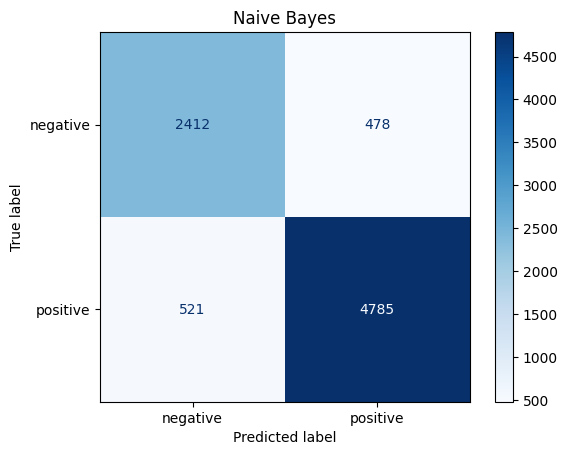

<Figure size 500x500 with 0 Axes>

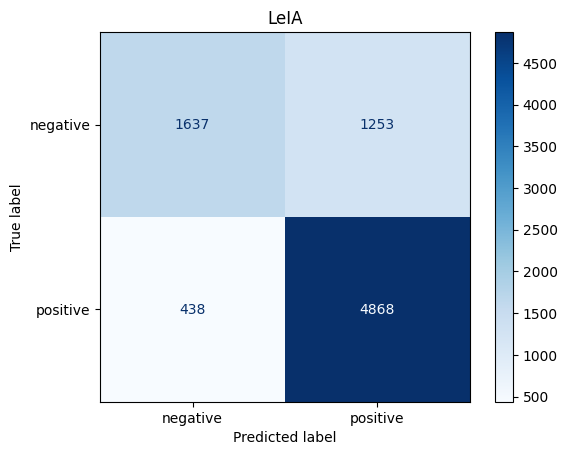

<Figure size 500x500 with 0 Axes>

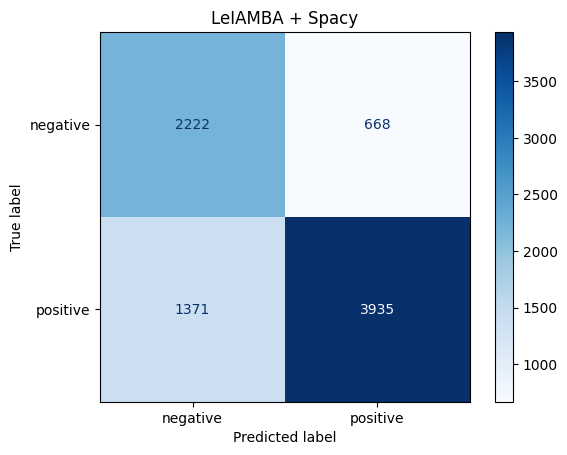

<Figure size 500x500 with 0 Axes>

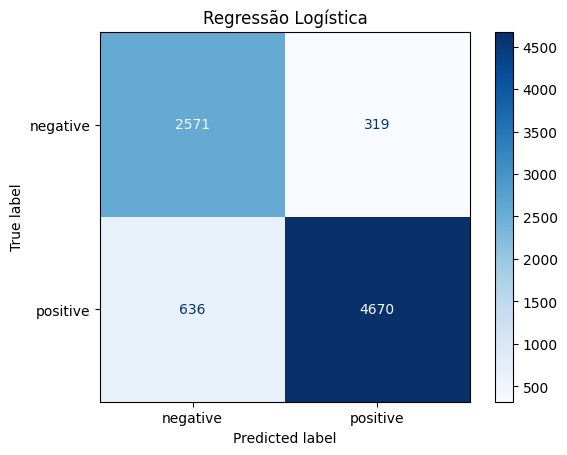

<Figure size 500x500 with 0 Axes>

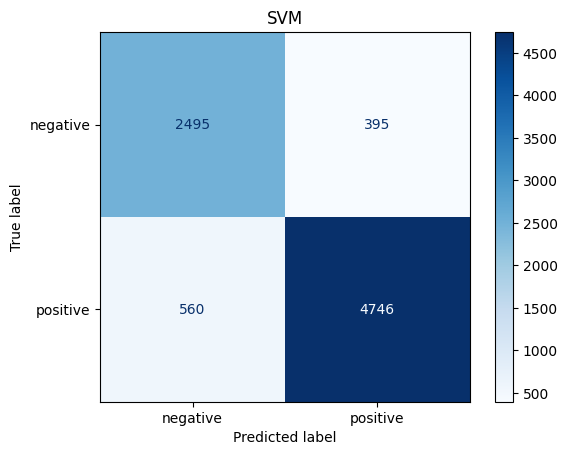

In [ ]:
model = {
    "Naive Bayes": pred_nb,
    "LeIA": pred_leia,
    "LeIAMBA + Spacy": pred_leiaMBA_spaCy,
    "Regressão Logística": pred_lr,
    "SVM": pred_svm
}

for name, pred in model.items():
    plt.figure(figsize=(5, 5))
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        pred,
        cmap="Blues"
    )
    plt.title(name)
    plt.show()

In [ ]:
import numpy as np
from scipy.sparse import hstack

def comparation_models(phrase):
    print("=" * 100)
    print(f"phrase: {phrase}\n")

    compound = leia.polarity_scores(phrase)["compound"]

    if compound >= 0:
        pred_leia = "positive"
    else:
        pred_leia = "negative"


    compound_spacy = leia_mba.polarity_scores(phrase)["compound"]

    if compound_spacy >= 0:
        pred_spacy = "positive"
    else:
        pred_spacy = "negative"

    # TF-IDF
    tfidf = vectorizer.transform([phrase])

    # Naive Bayes
    pred_nb = model_nb.predict(tfidf)[0]

    # Regressão Logística
    pred_lr = model_lr.predict([phrase])[0]

    # SVM
    pred_svm = model_svm.predict(tfidf)[0]

    print(f"{'Model':25} {'Prediction'}")
    print("-"*45)
    print(f"{'LeIA':25} {pred_leia} ({compound:.3f})")
    print(f"{'LeIA + spaCy':25} {pred_spacy} ({compound_spacy:.3f})")
    print(f"{'Naive Bayes':25} {pred_nb} ({acc_nb :.3f})")
    print(f"{'Regressão Logística':25} {pred_lr} ({acc_lr :.3f})")
    print(f"{'SVM':25} {pred_svm} ({acc_svm :.3f})")

In [ ]:
comparation_models("Não gostei da cor do produto")

phrase: Não gostei da cor do produto

Model                     Prediction
---------------------------------------------
LeIA                      positive (0.153)
LeIA + spaCy              positive (0.153)
Naive Bayes               positive (0.878)
Regressão Logística       negative (0.883)
SVM                       negative (0.883)


In [ ]:
comparation_models("Nossa que entrega ótima... demorou 1 mes para chegar")

phrase: Nossa que entrega ótima... demorou 1 mes para chegar

Model                     Prediction
---------------------------------------------
LeIA                      negative (-0.153)
LeIA + spaCy              positive (0.226)
Naive Bayes               positive (0.878)
Regressão Logística       negative (0.883)
SVM                       negative (0.883)


In [ ]:
comparation_models("Cinco estrelas para essa experiência horrível.")

phrase: Cinco estrelas para essa experiência horrível.

Model                     Prediction
---------------------------------------------
LeIA                      negative (-0.649)
LeIA + spaCy              negative (-0.649)
Naive Bayes               negative (0.878)
Regressão Logística       negative (0.883)
SVM                       positive (0.883)


In [ ]:
comparation_models("Excelente, perdi meu dinheiro")

phrase: Excelente, perdi meu dinheiro

Model                     Prediction
---------------------------------------------
LeIA                      positive (0.625)
LeIA + spaCy              positive (0.625)
Naive Bayes               negative (0.878)
Regressão Logística       negative (0.883)
SVM                       negative (0.883)


In [ ]:
comparation_models("Adorei pagar caro por um produto que nem funciona.")

phrase: Adorei pagar caro por um produto que nem funciona.

Model                     Prediction
---------------------------------------------
LeIA                      positive (0.382)
LeIA + spaCy              positive (0.382)
Naive Bayes               negative (0.878)
Regressão Logística       negative (0.883)
SVM                       negative (0.883)


In [ ]:
comparation_models("péssimo")

phrase: péssimo

Model                     Prediction
---------------------------------------------
LeIA                      positive (0.000)
LeIA + spaCy              negative (-0.612)
Naive Bayes               negative (0.878)
Regressão Logística       negative (0.883)
SVM                       negative (0.883)


In [ ]:
for phrase in df["review_comment_message"].head(1000):
    comparation_models(phrase)

A saída de streaming foi truncada nas últimas 5000 linhas.

Model                     Prediction
---------------------------------------------
LeIA                      positive (0.718)
LeIA + spaCy              positive (0.718)
Naive Bayes               positive (0.878)
Regressão Logística       positive (0.883)
SVM                       positive (0.883)
phrase: Adega veio quebrada e fornecedor não retornou contato! Tive que cancelar o pedido 

Model                     Prediction
---------------------------------------------
LeIA                      negative (-0.541)
LeIA + spaCy              negative (-0.541)
Naive Bayes               negative (0.878)
Regressão Logística       negative (0.883)
SVM                       negative (0.883)
phrase: o tempo de entrega foi menor que o esperado!

Model                     Prediction
---------------------------------------------
LeIA                      negative (-0.457)
LeIA + spaCy              negative (-0.457)
Naive Bayes              